In [6]:
!pip install xgboost openpyxl

In [7]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error

import pandas as pd

torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)

Using device: cuda


In [8]:
df = pd.read_excel('/content/Student_Performance.xlsx')

# Yes/No → 숫자 변환
df['Extracurricular Activities'] = df['Extracurricular Activities'].map({'Yes': 1, 'No': 0})

X = df.drop('Performance Index', axis=1).values
y = df['Performance Index'].values

print("Samples:", X.shape[0])
print("Features:", X.shape[1])
print(df.head())

Samples: 10000
Features: 5
   Hours Studied  Previous Scores  Extracurricular Activities  Sleep Hours  \
0              7               99                           1            9   
1              4               82                           0            4   
2              8               51                           1            7   
3              5               52                           1            5   
4              7               75                           0            8   

   Sample Question Papers Practiced  Performance Index  
0                                 1                 91  
1                                 2                 65  
2                                 2                 45  
3                                 2                 36  
4                                 5                 66  


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("✓ Data normalized")

✓ Data normalized


In [10]:
X_train_tensor = torch.FloatTensor(X_train_scaled)
y_train_tensor = torch.FloatTensor(y_train).reshape(-1, 1)
X_test_tensor = torch.FloatTensor(X_test_scaled)
y_test_tensor = torch.FloatTensor(y_test).reshape(-1, 1)

batch_size = 16
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print("Train batches:", len(train_loader))
print("Test batches:", len(test_loader))

Train batches: 500
Test batches: 125


In [11]:
class RegressionModel(nn.Module):
    def __init__(self, input_size, hidden1=64, hidden2=32):
        super().__init__()
        self.fc1 = nn.Linear(input_size, hidden1)
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Linear(hidden1, hidden2)
        self.relu2 = nn.ReLU()
        self.fc3 = nn.Linear(hidden2, 1)

    def forward(self, x):
        x = self.relu1(self.fc1(x))
        x = self.relu2(self.fc2(x))
        return self.fc3(x)

input_size = X_train_scaled.shape[1]   # 네 데이터는 feature 5개
model = RegressionModel(input_size).to(device)
print(model)

RegressionModel(
  (fc1): Linear(in_features=5, out_features=64, bias=True)
  (relu1): ReLU()
  (fc2): Linear(in_features=64, out_features=32, bias=True)
  (relu2): ReLU()
  (fc3): Linear(in_features=32, out_features=1, bias=True)
)


In [12]:
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print("Loss:", criterion)
print("Optimizer: Adam")

Loss: MSELoss()
Optimizer: Adam


In [ ]:
num_epochs = 100

train_losses = []
test_losses = []

print("Training...")

for epoch in range(num_epochs):
    model.train()
    train_loss = 0.0

    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        predictions = model(X_batch)
        loss = criterion(predictions, y_batch)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    avg_train = train_loss / len(train_loader)
    train_losses.append(avg_train)

    # test
    model.eval()
    test_loss = 0.0
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            pred = model(X_batch)
            loss = criterion(pred, y_batch)
            test_loss += loss.item()

    avg_test = test_loss / len(test_loader)
    test_losses.append(avg_test)

    if (epoch+1) % 10 == 0:
        print(f"Epoch {epoch+1}/{num_epochs} | Train {avg_train:.4f} | Test {avg_test:.4f}")


Training...
Epoch 10/100 | Train 4.4663 | Test 4.6182
Epoch 20/100 | Train 4.4370 | Test 4.4977
Epoch 30/100 | Train 4.3474 | Test 4.8538


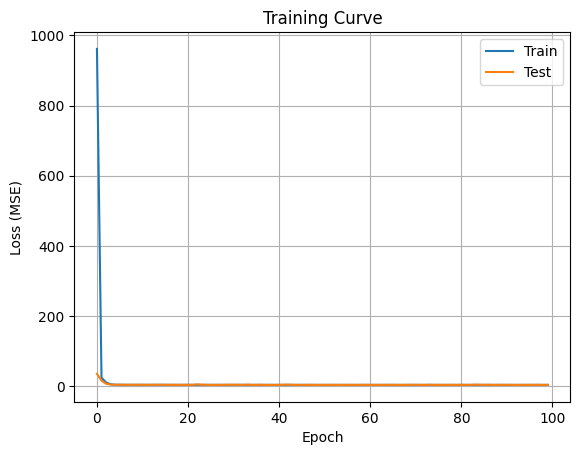

In [ ]:
plt.plot(train_losses, label='Train')
plt.plot(test_losses, label='Test')
plt.xlabel("Epoch")
plt.ylabel("Loss (MSE)")
plt.title("Training Curve")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
model.eval()
with torch.no_grad():
    preds = model(X_test_tensor.to(device)).cpu().numpy().reshape(-1)

mse = mean_squared_error(y_test, preds)
r2 = r2_score(y_test, preds)

print("Final MSE:", mse)
print("R2 Score:", r2)

Final MSE: 4.362696170806885
R2 Score: 0.9882275462150574


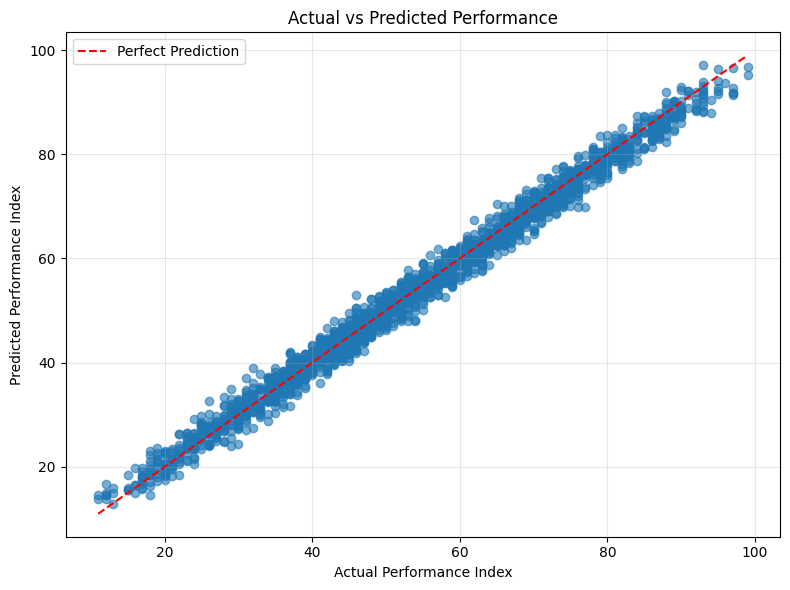


Sample Predictions (first 10 students):
--------------------------------------------------
    Actual |  Predicted |       Diff
--------------------------------------------------
     51.00 |      53.95 |      -2.95
     20.00 |      22.69 |      -2.69
     46.00 |      47.55 |      -1.55
     28.00 |      31.68 |      -3.68
     41.00 |      42.19 |      -1.19
     59.00 |      58.23 |       0.77
     48.00 |      45.87 |       2.13
     87.00 |      86.35 |       0.65
     37.00 |      37.29 |      -0.29
     73.00 |      71.87 |       1.13


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 1) 산점도: 실제값 vs 예측값
plt.figure(figsize=(8, 6))
plt.scatter(y_test, preds, alpha=0.6)
plt.plot([min(y_test), max(y_test)],
         [min(y_test), max(y_test)],
         'r--', label='Perfect Prediction')
plt.xlabel('Actual Performance Index')
plt.ylabel('Predicted Performance Index')
plt.title('Actual vs Predicted Performance')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 2) 일부 예측값 텍스트로 출력 (옵션)
print("\nSample Predictions (first 10 students):")
print("-" * 50)
print(f"{'Actual':>10} | {'Predicted':>10} | {'Diff':>10}")
print("-" * 50)
for a, p in list(zip(y_test, preds))[:10]:
    diff = a - p
    print(f"{a:10.2f} | {p:10.2f} | {diff:10.2f}")

In [ ]:
torch.save(model.state_dict(), 'student_performance_model.pth')
print("Model saved!")

Model saved!


In [ ]:
model = RegressionModel(input_size)
model.load_state_dict(torch.load('student_performance_model.pth', map_location=device))
model.to(device)
model.eval()

RegressionModel(
  (fc1): Linear(in_features=5, out_features=64, bias=True)
  (relu1): ReLU()
  (fc2): Linear(in_features=64, out_features=32, bias=True)
  (relu2): ReLU()
  (fc3): Linear(in_features=32, out_features=1, bias=True)
)